# CS 5864 Homework 4, Part 2: Diffusion

Follow the lead / steps from the [UC Berkeley assignment](https://cal-cs180.github.io/fa24/hw/proj5/partb.html) for this to the extent they don't conflict with the instructions on Canvas.

## Setup your environment

In [1]:
# Import essential modules. Feel free to add whatever you need.
import matplotlib.pyplot as plt
import torch # added
from torch import optim # added
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor

## Visualization helper function

In [2]:
def visualize_images_with_titles(images: torch.Tensor, column_names: list[str]):
    """
    Visualize images as a grid and title the columns with the provided names.

    Args:
        images: (N, C, H, W) tensor of images, where N is (number of rows * number of columns)
        column_names: List of column names for the titles.

    Example usage:
    visualize_images_with_titles(torch.randn(16, 1, 32, 32), ['1', '2', '3', '4'])
    """
    num_images, num_columns = images.shape[0], len(column_names)
    assert num_images % num_columns == 0, 'Number of images must be a multiple of the number of columns.'

    num_rows = num_images // num_columns
    fig, axes = plt.subplots(num_rows, num_columns, figsize=(num_columns * 1, num_rows * 1))

    for i, ax in enumerate(axes.flat):
        img = images[i].permute(1, 2, 0).cpu().numpy()
        ax.imshow(img, cmap='gray')
        ax.axis('off')
        if i < num_columns:
            ax.set_title(column_names[i % num_columns])

    plt.tight_layout()
    plt.show()

# Part 1: Training a Single-step Denoising UNet

## Implementing Simple and Composed Ops

In [2]:
from re import X


class Conv(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, 1, 1),
            nn.BatchNorm2d(out_channels),
            nn.GELU()
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.conv(x)
        # raise NotImplementedError()


class DownConv(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.downconv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, 2, 1),
            nn.BatchNorm2d(out_channels),
            nn.GELU()
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.downconv(x)
        # raise NotImplementedError()


class UpConv(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.upconv = nn.Sequential(
            nn.ConvTranspose2d(in_channels, out_channels, 4, 2, 1),
            nn.BatchNorm2d(out_channels),
            nn.GELU()
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.upconv(x)
        # raise NotImplementedError()


class Flatten(nn.Module):
    def __init__(self):
        super().__init__()
        self.faltten = nn.Sequential(
            nn.AvgPool2d(7),
            nn.GELU()
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.faltten(x)
        # raise NotImplementedError()


class Unflatten(nn.Module):
    def __init__(self, in_channels: int):
        super().__init__()
        self.unflatten = nn.Sequential(
            nn.ConvTranspose2d(in_channels, in_channels, 7, 7, 0),
            nn.BatchNorm2d(in_channels),
            nn.GELU()
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.unflatten(x)
        # raise NotImplementedError()


class ConvBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.convblock = nn.Sequential(
            Conv(in_channels, out_channels),
            Conv(out_channels, out_channels) 
        )
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.convblock(x)
        # raise NotImplementedError()


class DownBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.downblock = nn.Sequential(
            DownConv(in_channels, out_channels),
            ConvBlock(out_channels, out_channels)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.downblock(x)
        # raise NotImplementedError()


class UpBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.upblock = nn.Sequential(
            UpConv(in_channels, out_channels),
            ConvBlock(out_channels, out_channels)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.upblock(x)
        # raise NotImplementedError()

## Implementing Unconditional UNet

In [8]:
class UnconditionalUNet(nn.Module):
    def __init__(
        self,
        in_channels: int,
        num_hiddens: int,
    ):
        super().__init__()
        
        D = num_hiddens
        
        self.convblock1 = ConvBlock(in_channels, D)
        self.downblock1 = DownBlock(D, D)
        self.downblock2 = DownBlock(D, 2 * D)
        
        self.flatten = Flatten()
        self.unflatten = Unflatten(2 * D)
        
        self.upblock2 = UpBlock(4 * D, D)
        self.upblock1 = UpBlock(2 * D, D)
        
        self.convblock2 = ConvBlock(2 * D, D)
        self.conv2d = nn.Conv2d(D, in_channels, 3, 1, 1)
          

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        assert x.shape[-2:] == (28, 28), "Expect input shape to be (28, 28)."
        down0 = self.convblock1(x) # 1 conv
        down1 = self.downblock1(down0) # down 1
        down2 = self.downblock2(down1) # down 2
        
        mid = self.flatten(down2)
        mid = self.unflatten(mid)
        
        up0 = torch.cat([down2, mid], dim=1)
        
        up2 = self.upblock2(up0)
        up_1 = torch.cat([down1, up2], dim=1)
        up1 = self.upblock1(up_1)
        
        out = torch.cat([down0, up1], dim=1)
        out = self.convblock2(out)
        out = self.conv2d(out)
        
        return out
        
        # raise NotImplementedError()

## Visualizing the noising process

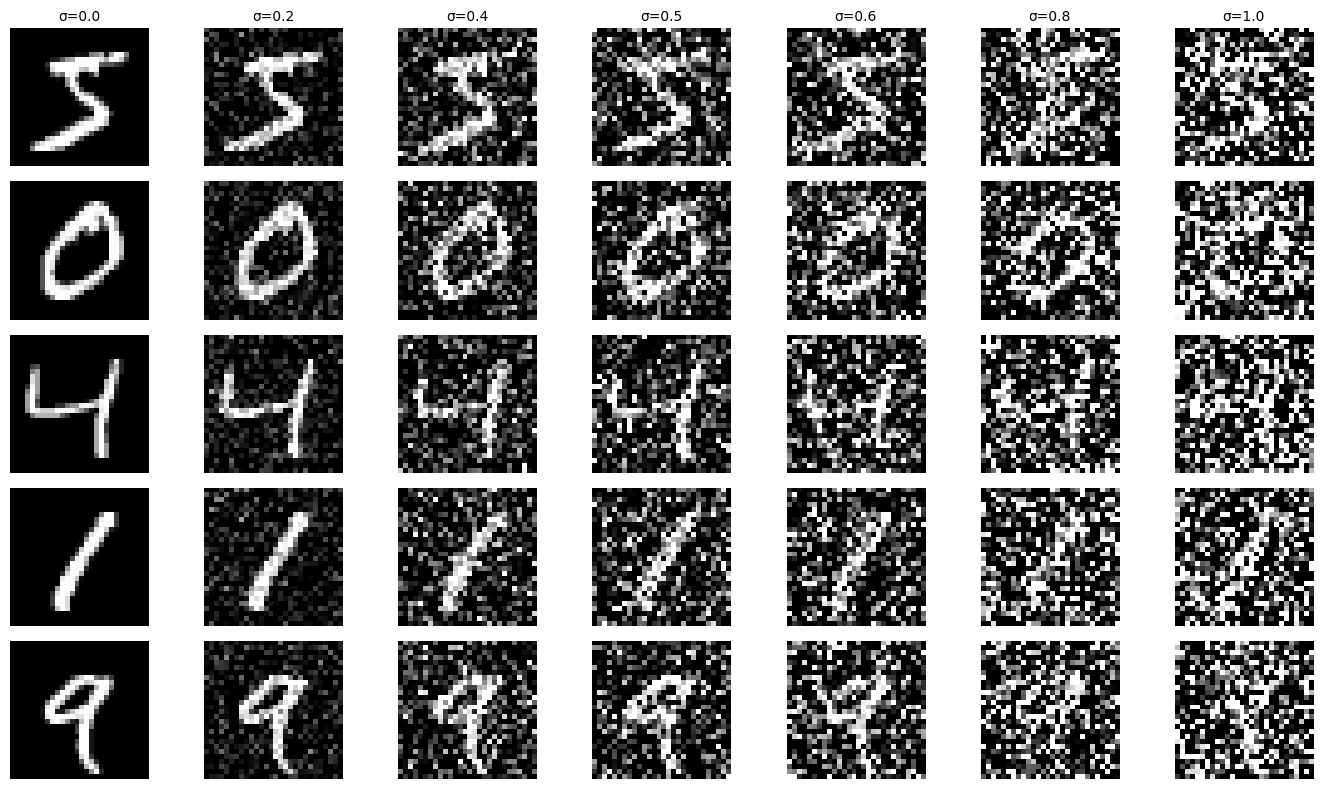

In [9]:
dataset = MNIST(root="data", download=True, transform=ToTensor(), train=True)

# TODO

sigmas = [0.0, 0.2, 0.4, 0.5, 0.6, 0.8, 1.0]

def add_noise(x, sigma):
    noise = torch.randn_like(x)
    z = x + sigma * noise
    return torch.clamp(z, 0.0, 1.0)  # keep valid range


rows = 5
fig, axes = plt.subplots(rows, len(sigmas), figsize=(14, 8))

data = [dataset[i] for i in range(rows)]
for row, (x, _) in enumerate(data):
    x = x.squeeze(0)  # (28, 28)

    for i, sigma in enumerate(sigmas):
        z = add_noise(x, sigma)
        axes[row, i].imshow(z.numpy(), cmap="gray")
        if row == 0:  # only label the top row
            axes[row, i].set_title(f"σ={sigma}", fontsize=10)
        axes[row, i].axis("off")

plt.tight_layout()
plt.show()


## Training a Single-Step Unconditional UNet

- Plot the loss curve
- Sample results on the test set

Epoch 1/5


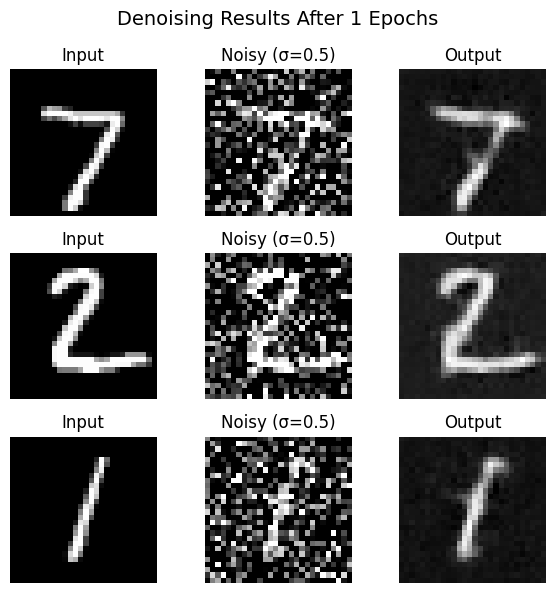

Epoch 1 - Loss: 0.0120
Epoch 2/5
Epoch 2 - Loss: 0.0115
Epoch 3/5
Epoch 3 - Loss: 0.0102
Epoch 4/5
Epoch 4 - Loss: 0.0097
Epoch 5/5


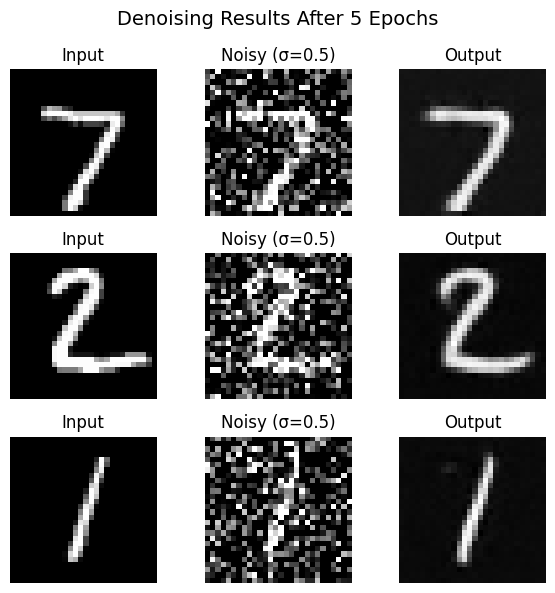

Epoch 5 - Loss: 0.0088


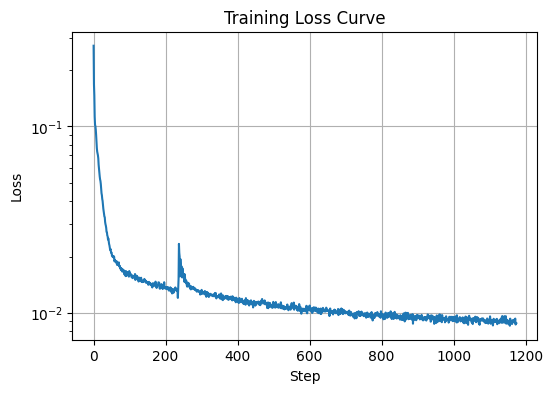

In [10]:
dataset = MNIST(root='data', download=True, transform=ToTensor(), train=True)
dataloader = DataLoader(dataset, batch_size=256, shuffle=True)

test_dataset = MNIST(root="data", download=True, transform=ToTensor(), train=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# TODO
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def visualize_denoising(model, dataloader, device, epoch, sigma=0.5, num_samples=3):
    model.eval()
    x, _ = next(iter(dataloader))  
    x = x[:num_samples].to(device)

    # Add Noise
    noisy_x = add_noise(x, sigma)

    # Denoise
    with torch.no_grad():
        output = model(noisy_x)

    x = x.cpu()
    noisy_x = noisy_x.cpu()
    output = output.cpu()

    fig, axs = plt.subplots(num_samples, 3, figsize=(6, 6))

    for i in range(num_samples):
        axs[i, 0].imshow(x[i][0], cmap="gray")
        axs[i, 0].set_title("Input")
        axs[i, 0].axis("off")

        axs[i, 1].imshow(noisy_x[i][0], cmap="gray")
        axs[i, 1].set_title(f"Noisy (σ={sigma})")
        axs[i, 1].axis("off")

        axs[i, 2].imshow(output[i][0], cmap="gray")
        axs[i, 2].set_title("Output")
        axs[i, 2].axis("off")

    plt.suptitle(f"Denoising Results After {epoch} Epochs", fontsize=14)
    plt.tight_layout()
    plt.show()

# Hyperparameters
sigma = 0.5
num_epochs = 5
batch_size = 256
learning_rate = 1e-4

model = UnconditionalUNet(in_channels=1, num_hiddens=128).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

criterion = nn.MSELoss()

losses = []

for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}/{num_epochs}")
    for x, _ in dataloader:
        x = x.to(device)
        noisy_x = add_noise(x, sigma)

        optimizer.zero_grad()
        output = model(noisy_x)
        loss = criterion(output, x)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
    
    if epoch+1 == 1 or epoch+1 == 5:
        visualize_denoising(model, test_loader, device, epoch+1)

    print(f"Epoch {epoch+1} - Loss: {losses[-1]:.4f}")
    
plt.figure(figsize=(6,4))
plt.plot(losses)
plt.yscale('log')
plt.title("Training Loss Curve")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.grid(True)
plt.show()


## Out-of-Distribution Testing

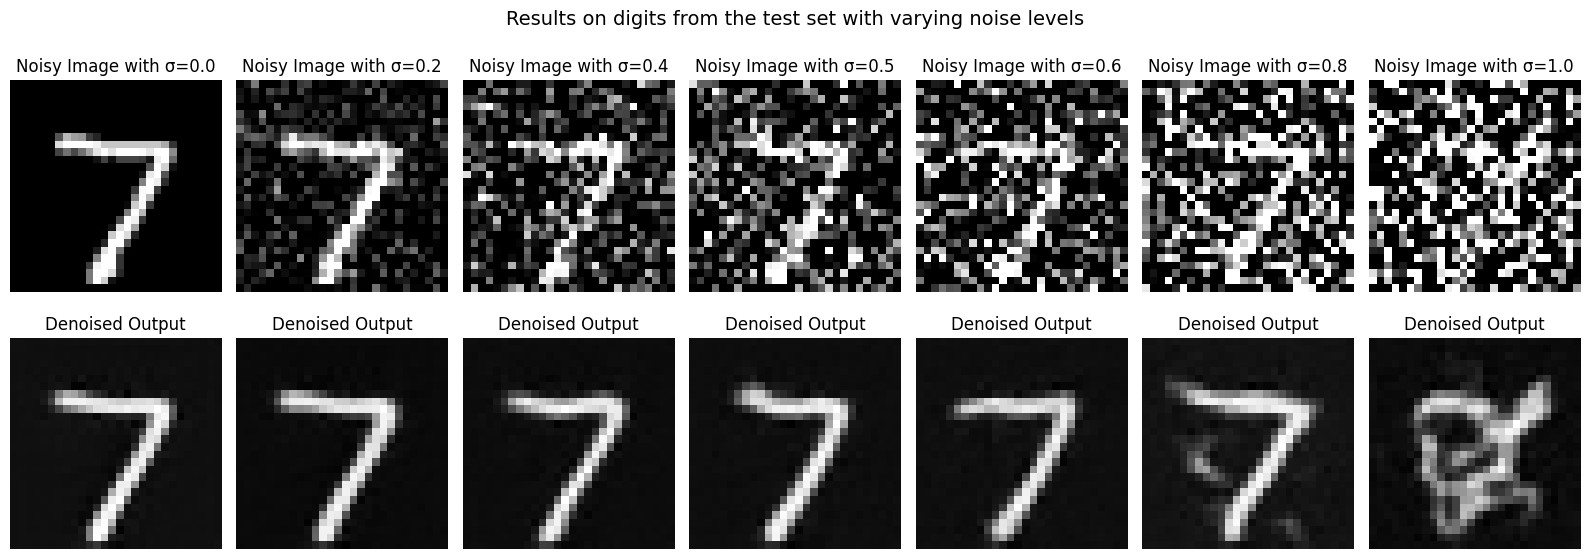

In [11]:
# TODO

def visualize_varying_noise(model, dataloader, device, sigmas):
    model.eval()
    x, _ = next(iter(dataloader))  # Test data
    x = x[:1].to(device)  

    fig, axs = plt.subplots(2, len(sigmas), figsize=(16, 6))

    for i, sigma in enumerate(sigmas):
        # Add noise
        noisy_x = add_noise(x, sigma)

        # Denoise
        with torch.no_grad():
            output = model(noisy_x)

        # Convert to cpu and numpy for plotting
        noisy_display = noisy_x[0, 0].cpu().numpy()
        output_display = output[0, 0].cpu().numpy()

        # Plot noisy
        axs[0, i].imshow(noisy_display, cmap="gray")
        axs[0, i].set_title(f"Noisy Image with σ={sigma}")
        axs[0, i].axis("off")

        # Plot denoised
        axs[1, i].imshow(output_display, cmap="gray")
        axs[1, i].set_title("Denoised Output")
        axs[1, i].axis("off")
        
    


    plt.suptitle("Results on digits from the test set with varying noise levels", fontsize=14)
    plt.tight_layout()
    plt.show()
    
    

sigmas = [0.0, 0.2, 0.4, 0.5, 0.6, 0.8, 1.0]

visualize_varying_noise(model, test_loader, device, sigmas)



# Part 2: Training a Diffusion Model

## Implementing a Time-conditioned UNet

In [11]:
class FCBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.fcblock = nn.Sequential(
            nn.Linear(in_channels, out_channels),
            nn.GELU(),
            nn.Linear(out_channels, out_channels)
        )
        

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.fcblock(x)
        # raise NotImplementedError()


class TimeConditionalUNet(nn.Module):
    def __init__(
        self,
        in_channels: int,
        # num_classes: int,
        num_hiddens: int,
    ):
        super().__init__()
        
        D = num_hiddens
        
        self.conv1 = ConvBlock(in_channels, D)
        self.down1 = DownBlock(D, D)
        self.down2 = DownBlock(D, 2 * D)
        
        self.flatten = Flatten()
        self.unflatten = Unflatten(2*D)
        
        self.fc1 = FCBlock(1, 2 * D)
        
        self.up1 = UpBlock(4 * D, D)
        self.up2 = UpBlock(2 * D, D)
        
        self.fc2 = FCBlock(1, D)
        
        self.conv2 = ConvBlock(2 * D, D)
        self.final = nn.Conv2d(D, in_channels, 3, 1, 1)

    def forward(
        self,
        x: torch.Tensor,
        t: torch.Tensor,
    ) -> torch.Tensor:
        """
        Args:
            x: (N, C, H, W) input tensor.
            t: (N,) normalized time tensor.

        Returns:
            (N, C, H, W) output tensor.
        """
        assert x.shape[-2:] == (28, 28), "Expect input shape to be (28, 28)."
        
        B, _, _, _ = x.shape
        down0 = self.conv1(x)
        down1 = self.down1(down0)
        down2 = self.down2(down1)
        
        flatten = self.flatten(down2)
        unflatten = self.unflatten(flatten)
        
        # t_in = t.float().view(B, 1)
        t1 = self.fc1(t)
        t1 = t1.view(B, -1, 1, 1)
        unflatten = unflatten + t1
        
        up1 = self.up1(torch.cat([down2, unflatten], dim=1))
        
        t2 = self.fc2(t)
        t2 = t2.view(B, -1, 1, 1)
        up1 = up1 + t2
        
        up2 = self.up2(torch.cat([down1, up1], dim=1))
        
        out = torch.cat([down0, up2], dim=1)
        out = self.conv2(out)
        
        out = self.final(out)
        return out
        
        # raise NotImplementedError()

## Implementing DDPM Forward and Inverse Process for Time-conditioned Denoising

In [20]:
def ddpm_schedule(beta1: float, beta2: float, num_ts: int) -> dict:
    """Constants for DDPM training and sampling.

    Arguments:
        beta1: float, starting beta value.
        beta2: float, ending beta value.
        num_ts: int, number of timesteps.

    Returns:
        dict with keys:
            betas: linear schedule of betas from beta1 to beta2.
            alphas: 1 - betas.
            alpha_bars: cumulative product of alphas.
    """
    assert beta1 < beta2 < 1.0, "Expect beta1 < beta2 < 1.0."
    
    betas = torch.linspace(beta1, beta2, num_ts)
    
    alphas = 1.0 - betas
    
    alpha_bars = torch.cumprod(alphas, dim=0)
    
    return {
        "betas": betas,
        "alphas": alphas,
        "alpha_bars": alpha_bars,
    }

    # raise NotImplementedError()

In [6]:
def ddpm_forward(
    unet: TimeConditionalUNet,
    ddpm_schedule: dict,
    x_0: torch.Tensor,
    num_ts: int,
) -> torch.Tensor:
    """Algorithm 1 of the DDPM paper.

    Args:
        unet: TimeConditionalUNet
        ddpm_schedule: dict
        x_0: (N, C, H, W) input tensor.
        num_ts: int, number of timesteps.
    Returns:
        (,) diffusion loss.
    """
    unet.train()
    # YOUR CODE HERE.
    device = x_0.device
    N = x_0.size(0)

    # Retrieve schedule components
    alpha_bars = ddpm_schedule["alpha_bars"].to(device)
    
    t = torch.randint(0, num_ts, size=(N,), device=device)
    
    
    eps = torch.randn_like(x_0)
    
    # alpha_bar_t = alpha_bars[t].view(N, 1, 1, 1)
    alpha_bar_t = alpha_bars[t].view(N, 1, 1, 1)

    x_t = torch.sqrt(alpha_bar_t) * x_0 + torch.sqrt(1.0 - alpha_bar_t) * eps
    
    # t_norm = t.float() / (num_ts - 1)
    t_norm = t.unsqueeze(-1).float() / (num_ts - 1)
    # t_norm = t_norm.view(N, 1)
    eps_hat = unet(x_t, t_norm)
    # eps_hat = torch.tanh(eps_hat)
    loss = torch.mean((eps - eps_hat) ** 2)
    
    return loss
    
    # raise NotImplementedError()

In [ ]:
@torch.inference_mode()
def ddpm_sample(
    unet: TimeConditionalUNet,
    ddpm_schedule: dict,
    img_wh: tuple[int, int],
    num_ts: int,
    seed: int = 0,
) -> torch.Tensor:
    """Algorithm 2 of the DDPM paper with classifier-free guidance.

    Args:
        unet: TimeConditionalUNet
        ddpm_schedule: dict
        img_wh: (H, W) output image width and height.
        num_ts: int, number of timesteps.
        seed: int, random seed.

    Returns:
        (N, C, H, W) final sample.
    """
    unet.eval()
    # YOUR CODE HERE.
    torch.manual_seed(seed)
    device = next(unet.parameters()).device

    # Retrieve schedule constants
    betas = ddpm_schedule["betas"].to(device)
    alphas = ddpm_schedule["alphas"].to(device)
    alpha_bars = ddpm_schedule["alpha_bars"].to(device)
    
    # Sampling starts from pure noise
    N = 40
    C, H, W = 1, img_wh[0], img_wh[1]
    x_t = torch.randn((N, C, H, W), device=device)
 
        # for t = T -> 1
    for t in reversed(range(1, num_ts)):
            
        t_tensor = torch.tensor([t] * N, device=device).float()
        t_tensor = (t_tensor / (num_ts - 1)).view(N, 1)

        eps_theta = unet(x_t, t_tensor)

        # Compute x_{t-1} mean
        alpha = alphas[t].view(1,1,1,1)
        alpha_bar = alpha_bars[t].view(1,1,1,1).clamp(min=1e-8)
        beta = betas[t].view(1,1,1,1)
            
        x0_hat = (x_t - torch.sqrt(1 - alpha_bar) * eps_theta) / torch.sqrt(alpha_bar)
        alpha_bar_prev = alpha_bars[t-1].view(1,1,1,1)

        # sample z only if t > 0
        if t > 1:
            z = torch.randn_like(x_t)
        else:
            z = torch.zeros_like(x_t)
            # alpha_bar_prev = alpha_bar # unused
            # Compute mean of x_{t-1}
        coef1 = torch.sqrt(alpha_bar_prev) * beta / (1 - alpha_bar)
        coef2 = torch.sqrt(alpha) * (1 - alpha_bar_prev) / (1 - alpha_bar)
        
        # Correct DDPM sampling formula
        # pred_mean = (x_t - torch.sqrt(1-alpha) * eps_theta / torch.sqrt(1-alpha_bar)) / alpha.sqrt()
            
        x_t = coef1 * x0_hat + coef2 * x_t + torch.sqrt(beta) * z


     # Clip to valid pixel range
    x_0 = torch.clamp(x_t, 0.0, 1.0)
    # print(t, x_t.min().item(), x_t.max().item())
    return x_0
    # raise NotImplementedError()

In [8]:
class DDPM(nn.Module):
    def __init__(
        self,
        unet: TimeConditionalUNet,
        betas: tuple[float, float] = (1e-4, 0.02),
        num_ts: int = 300,
        p_uncond: float = 0.1,
    ):
        super().__init__()
        self.unet = unet
        self.num_ts = num_ts
        self.p_uncond = p_uncond

        # self.ddpm_schedule = nn.ParameterDict(ddpm_schedule(betas[0], betas[1], num_ts))
        self.ddpm_schedule = ddpm_schedule(betas[0], betas[1], num_ts)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (N, C, H, W) input tensor.

        Returns:
            (,) diffusion loss.
        """
        return ddpm_forward(
            self.unet, self.ddpm_schedule, x, self.num_ts
        )

    @torch.inference_mode()
    def sample(
        self,
        img_wh: tuple[int, int],
        seed: int = 0,
    ):
        return ddpm_sample(
            self.unet, self.ddpm_schedule, img_wh, self.num_ts, seed
        )

## Training the Time-conditioned UNet

- Plot the loss curve
- Sample results on the test set

Epoch [1/20] → Loss: 0.0720
Samples after 1 epochs


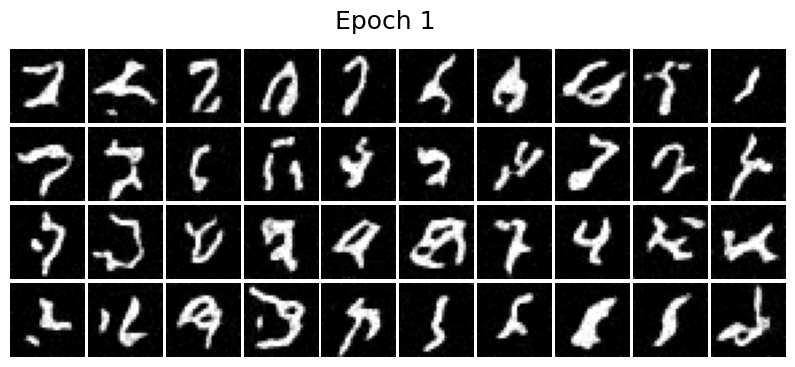

Epoch [2/20] → Loss: 0.0452
Epoch [3/20] → Loss: 0.0409
Epoch [4/20] → Loss: 0.0372
Epoch [5/20] → Loss: 0.0359
Samples after 5 epochs


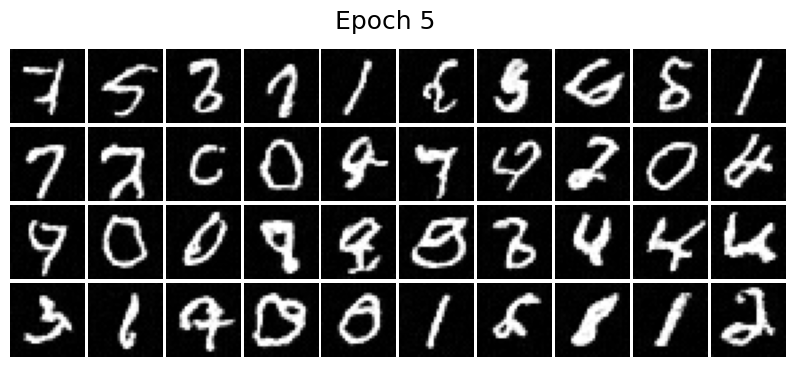

Epoch [6/20] → Loss: 0.0339
Epoch [7/20] → Loss: 0.0330
Epoch [8/20] → Loss: 0.0315
Epoch [9/20] → Loss: 0.0313
Epoch [10/20] → Loss: 0.0306
Samples after 10 epochs


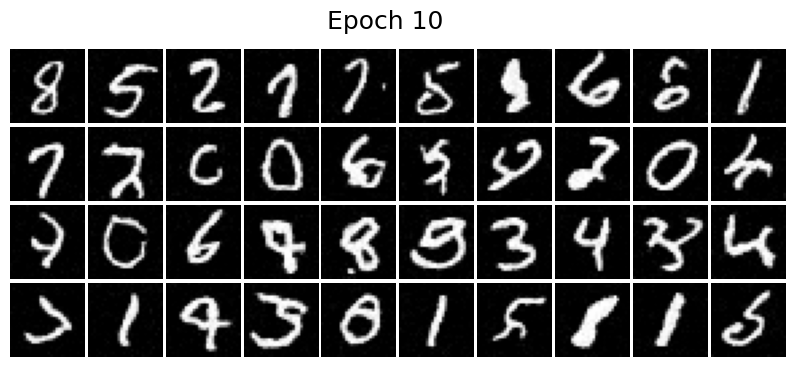

Epoch [11/20] → Loss: 0.0299
Epoch [12/20] → Loss: 0.0296
Epoch [13/20] → Loss: 0.0290
Epoch [14/20] → Loss: 0.0291
Epoch [15/20] → Loss: 0.0285
Samples after 15 epochs


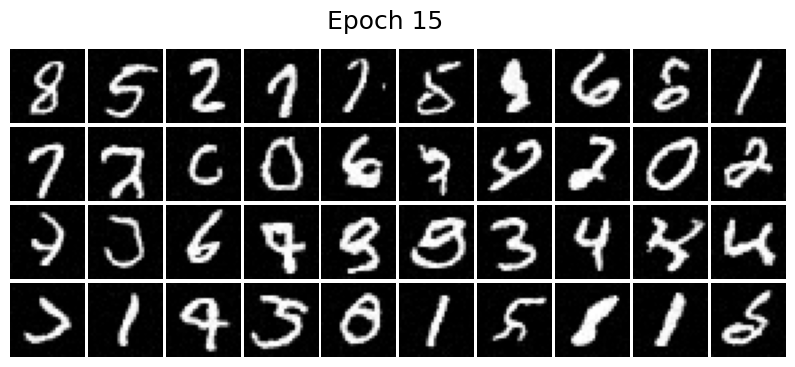

Epoch [16/20] → Loss: 0.0282
Epoch [17/20] → Loss: 0.0280
Epoch [18/20] → Loss: 0.0277
Epoch [19/20] → Loss: 0.0278
Epoch [20/20] → Loss: 0.0273
Samples after 20 epochs


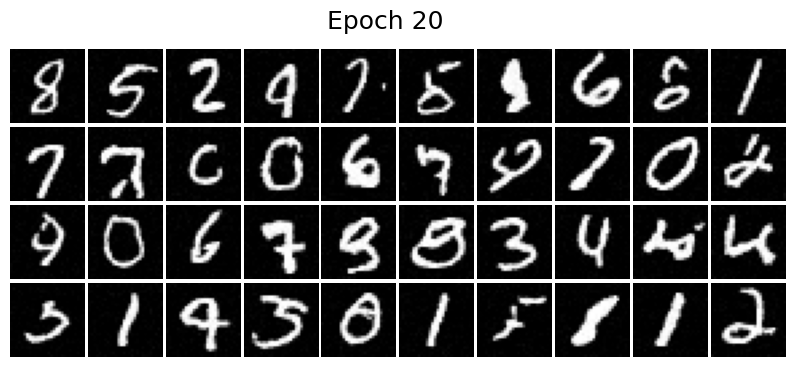

In [ ]:
dataset = MNIST(root='data', download=True, transform=ToTensor(), train=True)
dataloader = DataLoader(dataset, batch_size=128, shuffle=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# TODO

batch_size = 128
learning_rate = 1e-3
num_epochs = 20

unet = TimeConditionalUNet(in_channels=1, num_hiddens=64).to(device)
ddpm = DDPM(unet=unet).to(device)
optimizer = optim.Adam(ddpm.parameters(), lr=learning_rate, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.1 ** (1.0 / num_epochs))

train_losses = []

def show_grid(samples, epoch, n_rows=4, n_cols=10):
    """
    samples: (N, 1, H, W) tensor, in [0,1]
    """
    samples = samples.detach().cpu().numpy().squeeze()  # → (N, H, W)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols, n_rows))
    for ax, img in zip(axes.flat, samples):
        ax.imshow(img, cmap="gray", vmin=0.0, vmax=1.0)
        ax.axis("off")

    plt.subplots_adjust(wspace=0.05, hspace=0.05)
    fig.suptitle(f"Epoch {epoch}", fontsize=18)
    plt.show()
    
for epoch in range(num_epochs):
    # ddpm.train()
    epoch_loss = 0.0
    total_steps = 0

    for i, (x, _) in enumerate(dataloader):
        x = x.to(device)
        x = torch.clamp(x, 0.0, 1.0)

        optimizer.zero_grad()
        loss = ddpm(x)
        loss.backward()
        # torch.nn.utils.clip_grad_norm_(unet.parameters(), max_norm=1.0)
        optimizer.step()
        
        epoch_loss += loss.item()
        total_steps += 1

        train_losses.append(loss.item())
        # print(f"Epoch [{epoch+1}/{num_epochs}] → iteration: {i} -> loss: {loss.item():.4f}")

    scheduler.step()
    avg_loss = epoch_loss / total_steps
    # if not torch.isnan(avg_loss):
    print(f"Epoch [{epoch+1}/{num_epochs}] → Loss: {avg_loss:.4f}")

    # Save sampling results at target epochs
    if epoch+1 in [1, 5, 10, 15, 20]:
        # ddpm.eval()
        samples = ddpm.sample(img_wh=(28, 28), seed=0)  # (N, 1, 28,28)
        if epoch+1 == 1:
            samples_at_1 = samples.clone()
            print("Samples after 1 epochs")
            show_grid(samples_at_1, 1)
        if epoch+1 == 5:
            samples_at_5 = samples.clone()
            print("Samples after 5 epochs")
            show_grid(samples_at_5, 5)
        if epoch+1 == 10:
            samples_at_10 = samples.clone()
            print("Samples after 10 epochs")
            show_grid(samples_at_10, 10)
        if epoch+1 == 15:
            samples_at_15 = samples.clone()
            print("Samples after 15 epochs")
            show_grid(samples_at_15, 15)
        if epoch+1 == 20:
            samples_at_20 = samples.clone()
            print("Samples after 20 epochs")
            show_grid(samples_at_20, 20)
            


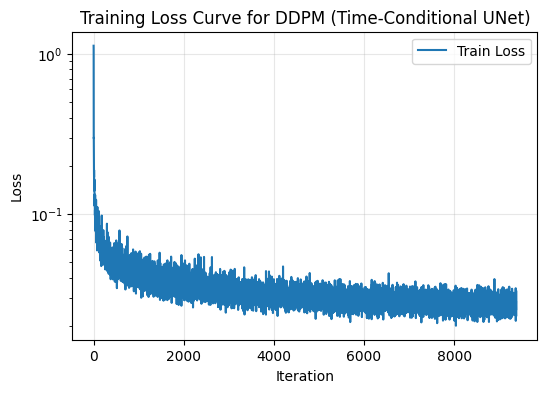

In [10]:
plt.figure(figsize=(6,4))
plt.plot(train_losses, label="Train Loss")
plt.yscale('log')
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training Loss Curve for DDPM (Time-Conditional UNet)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

### Implementing class-conditioned UNet

In [12]:
class ClassConditionalUNet(nn.Module):
    def __init__(
        self,
        in_channels: int,
        num_classes: int,
        num_hiddens: int,
    ):
        super().__init__()
        D = num_hiddens
        
        self.num_classes = num_classes
        
        self.conv1 = ConvBlock(in_channels, D)
        self.down1 = DownBlock(D, D)
        self.down2 = DownBlock(D, 2 * D)
        
        self.flatten = Flatten()
        self.unflatten = Unflatten(2*D)
        
        self.fc1_t = FCBlock(1, 2 * D)
        self.fc1_c = FCBlock(num_classes, 2 * D)
        
        self.up1 = UpBlock(4 * D, D)
        self.up2 = UpBlock(2 * D, D)
        
        self.fc2_t = FCBlock(1, D)
        self.fc2_c = FCBlock(num_classes, D)
        
        self.conv2 = ConvBlock(2 * D, D)
        self.final = nn.Conv2d(D, in_channels, 3, 1, 1)
        

    def forward(
        self,
        x: torch.Tensor,
        c: torch.Tensor,
        t: torch.Tensor,
        mask: torch.Tensor | None = None,
    ) -> torch.Tensor:
        """
        Args:
            x: (N, C, H, W) input tensor.
            c: (N,) int64 condition tensor.
            t: (N,) normalized time tensor.
            mask: (N,) mask tensor. If not None, mask out condition when mask == 0.

        Returns:
            (N, C, H, W) output tensor.
        """
        assert x.shape[-2:] == (28, 28), "Expect input shape to be (28, 28)."
        
        B, _, _, _ = x.shape
        down0 = self.conv1(x)
        down1 = self.down1(down0)
        down2 = self.down2(down1)
        
        flatten = self.flatten(down2)
        unflatten = self.unflatten(flatten)
        
        # c_onehot = F.one_hot(c, num_classes=self.num_classes).float().to(device) # [N, K]
        
        if mask is not None:
            c = c * mask[:, None]
        
        # t_in = t.float().view(B, 1)
        t1 = self.fc1_t(t)
        t1 = t1.view(B, -1, 1, 1)
        c1 = self.fc1_c(c)
        c1 = c1.view(B, -1, 1, 1)
        unflatten = c1 * unflatten + t1
        
        up1 = self.up1(torch.cat([down2, unflatten], dim=1))
        
        t2 = self.fc2_t(t)
        t2 = t2.view(B, -1, 1, 1)
        c2 = self.fc2_c(c)
        c2 = c2.view(B, -1, 1, 1)
        up1 = c2 * up1 + t2
        
        up2 = self.up2(torch.cat([down1, up1], dim=1))
        
        out = torch.cat([down0, up2], dim=1)
        out = self.conv2(out)
        
        out = self.final(out)
        return out
        
        # raise NotImplementedError()

In [13]:
def ddpm_forward(
    unet: ClassConditionalUNet,
    ddpm_schedule: dict,
    x_0: torch.Tensor,
    c: torch.Tensor,
    p_uncond: float,
    num_ts: int,
) -> torch.Tensor:
    """Algorithm 1 of the DDPM paper.

    Args:
        unet: ClassConditionalUNet
        ddpm_schedule: dict
        x_0: (N, C, H, W) input tensor.
        c: (N,) int64 condition tensor.
        p_uncond: float, probability of unconditioning the condition.
        num_ts: int, number of timesteps.

    Returns:
        (,) diffusion loss.
    """
    unet.train()
    # YOUR CODE HERE.
    device = x_0.device
    N = x_0.size(0)

    c_onehot = F.one_hot(c, num_classes=10).float().to(device)
    
    if p_uncond > 0.0:
        keep_mask = (torch.rand(N, device=device) > p_uncond).float().unsqueeze(-1)  # (N,1)
        c_onehot = c_onehot * keep_mask
        
    # Retrieve schedule components
    alpha_bars = ddpm_schedule["alpha_bars"].to(device)
    
    t = torch.randint(0, num_ts, size=(N,), device=device)
    
    eps = torch.randn_like(x_0)
    
    # alpha_bar_t = alpha_bars[t].view(N, 1, 1, 1)
    alpha_bar_t = alpha_bars[t].view(N, 1, 1, 1)

    x_t = torch.sqrt(alpha_bar_t) * x_0 + torch.sqrt(1.0 - alpha_bar_t) * eps
    
    # t_norm = t.float() / (num_ts - 1)
    t_norm = t.unsqueeze(-1).float() / (num_ts - 1)
    # t_norm = t_norm.view(N, 1)
    eps_hat = unet(x_t, c_onehot, t_norm)
    # eps_hat = torch.tanh(eps_hat)
    loss = torch.mean((eps - eps_hat) ** 2)
    
    return loss

In [14]:

@torch.inference_mode()
def ddpm_sample(
    unet: ClassConditionalUNet,
    ddpm_schedule: dict,
    c: torch.Tensor,
    img_wh: tuple[int, int],
    num_ts: int,
    guidance_scale: float = 5.0,
    seed: int = 0,
) -> torch.Tensor:
    """Algorithm 2 of the DDPM paper with classifier-free guidance.

    Args:
        unet: ClassConditionalUNet
        ddpm_schedule: dict
        c: (N,) int64 condition tensor. Only for class-conditional
        img_wh: (H, W) output image width and height.
        num_ts: int, number of timesteps.
        guidance_scale: float, CFG scale.
        seed: int, random seed.

    Returns:
        (N, C, H, W) final sample.
        (N, T_animation, C, H, W) caches.
    """
    unet.eval()
    # YOUR CODE HERE.
    torch.manual_seed(seed)
    device = next(unet.parameters()).device

    # Retrieve schedule constants
    betas = ddpm_schedule["betas"].to(device)
    alphas = ddpm_schedule["alphas"].to(device)
    alpha_bars = ddpm_schedule["alpha_bars"].to(device)
    
    samples = []
    
    # Sampling starts from pure noise
    for i in range(4):
        N = 10
        C, H, W = 1, img_wh[0], img_wh[1]
        x_t = torch.randn((N, C, H, W), device=device)
        c_onehot = F.one_hot(c, num_classes=10).float().to(device)
    
        # for t = T -> 1
        for t in reversed(range(1, num_ts)):
                
            t_tensor = torch.tensor([t] * N, device=device).float()
            t_tensor = (t_tensor / (num_ts - 1)).view(N, 1)

            zero_c = torch.zeros_like(c_onehot)
            eps_theta_u = unet(x_t, zero_c, t_tensor)
            eps_theta_c = unet(x_t, c_onehot, t_tensor)
            
            eps_theta = eps_theta_u + guidance_scale * (eps_theta_c - eps_theta_u)

            # Compute x_{t-1} mean
            alpha = alphas[t].view(1,1,1,1)
            alpha_bar = alpha_bars[t].view(1,1,1,1).clamp(min=1e-8)
            beta = betas[t].view(1,1,1,1)
                
            x0_hat = (x_t - torch.sqrt(1 - alpha_bar) * eps_theta) / torch.sqrt(alpha_bar)
            alpha_bar_prev = alpha_bars[t-1].view(1,1,1,1)

            # sample z only if t > 0
            if t > 1:
                z = torch.randn_like(x_t)
            else:
                z = torch.zeros_like(x_t)
                # alpha_bar_prev = alpha_bar # unused
                # Compute mean of x_{t-1}
            coef1 = torch.sqrt(alpha_bar_prev) * beta / (1 - alpha_bar)
            coef2 = torch.sqrt(alpha) * (1 - alpha_bar_prev) / (1 - alpha_bar)
            
                
            x_t = coef1 * x0_hat + coef2 * x_t + torch.sqrt(beta) * z


        # Clip to valid pixel range
        x_0 = torch.clamp(x_t, 0.0, 1.0)
        samples.append(x_0)

    # print(t, x_t.min().item(), x_t.max().item())
    samples = torch.cat(samples, dim=0)
    return samples

In [17]:
class DDPM(nn.Module):
    def __init__(
        self,
        unet: ClassConditionalUNet,
        betas: tuple[float, float] = (1e-4, 0.02),
        num_ts: int = 300,
        p_uncond: float = 0.1,
    ):
        super().__init__()
        self.unet = unet
        self.betas = betas
        self.num_ts = num_ts
        self.p_uncond = p_uncond
        self.ddpm_schedule = ddpm_schedule(betas[0], betas[1], num_ts)

    def forward(self, x: torch.Tensor, c: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (N, C, H, W) input tensor.
            c: (N,) int64 condition tensor.

        Returns:
            (,) diffusion loss.
        """
        return ddpm_forward(
            self.unet, self.ddpm_schedule, x, c, self.p_uncond, self.num_ts
        )

    @torch.inference_mode()
    def sample(
        self,
        c: torch.Tensor,
        img_wh: tuple[int, int],
        guidance_scale: float = 5.0,
        seed: int = 0,
    ):
        return ddpm_sample(
            self.unet, self.ddpm_schedule, c, img_wh, self.num_ts, guidance_scale, seed
        )

## Training the Class-conditioned UNet

- Plot the loss curve
- Sample results on the test set

Epoch [1/20] → Loss: 0.0704
Samples after 1 epochs


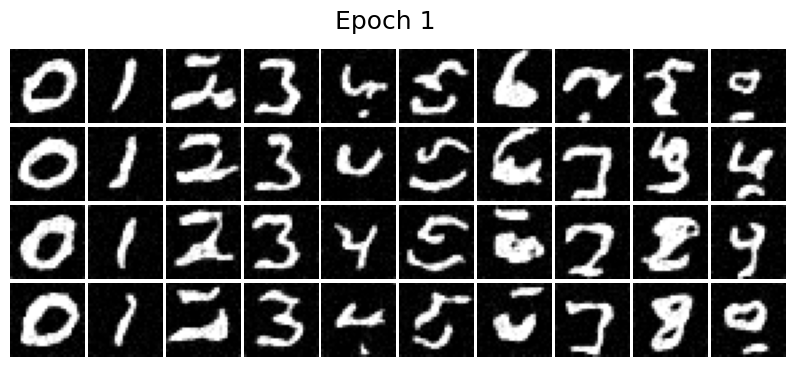

Epoch [2/20] → Loss: 0.0432
Epoch [3/20] → Loss: 0.0391
Epoch [4/20] → Loss: 0.0356
Epoch [5/20] → Loss: 0.0334
Samples after 5 epochs


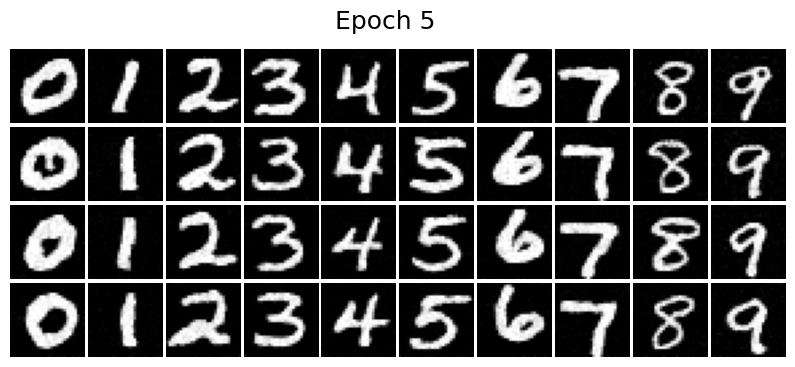

Epoch [6/20] → Loss: 0.0318
Epoch [7/20] → Loss: 0.0309
Epoch [8/20] → Loss: 0.0299
Epoch [9/20] → Loss: 0.0292
Epoch [10/20] → Loss: 0.0289
Samples after 10 epochs


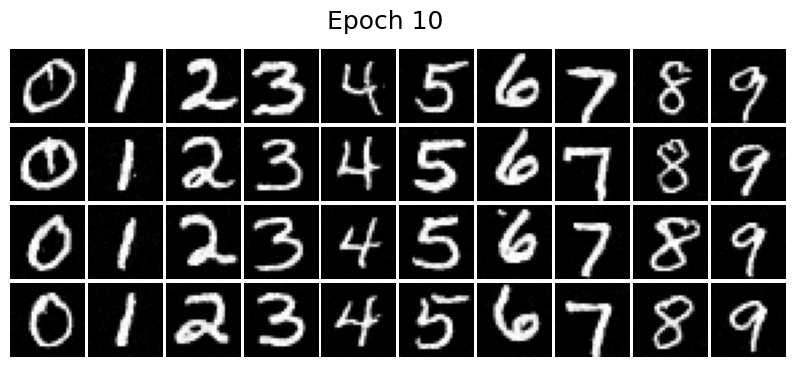

Epoch [11/20] → Loss: 0.0281
Epoch [12/20] → Loss: 0.0280
Epoch [13/20] → Loss: 0.0276
Epoch [14/20] → Loss: 0.0274
Epoch [15/20] → Loss: 0.0271
Samples after 15 epochs


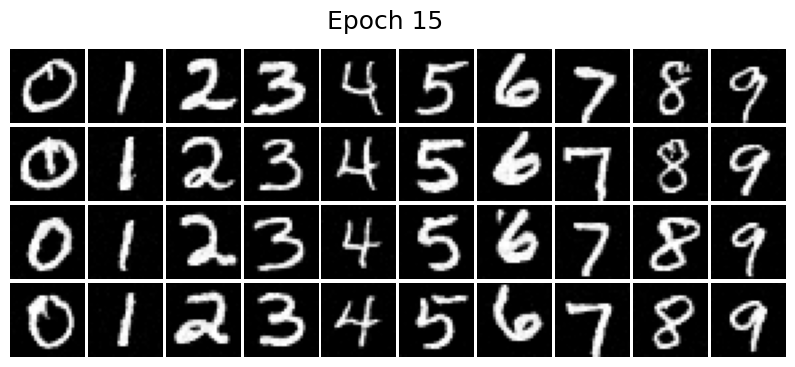

Epoch [16/20] → Loss: 0.0268
Epoch [17/20] → Loss: 0.0267
Epoch [18/20] → Loss: 0.0265
Epoch [19/20] → Loss: 0.0264
Epoch [20/20] → Loss: 0.0262
Samples after 20 epochs


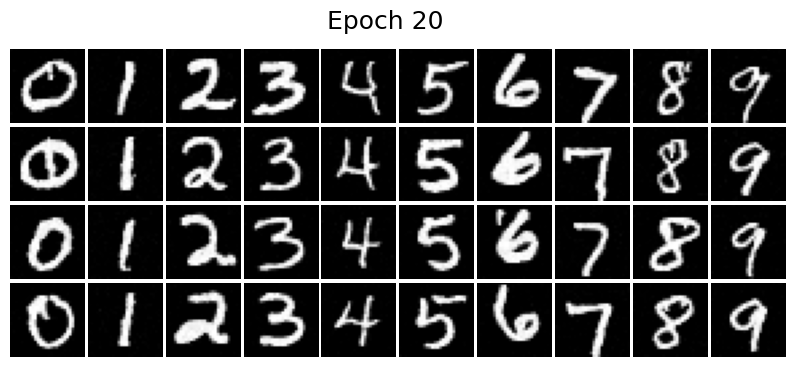

In [24]:
dataset = MNIST(root='data', download=True, transform=ToTensor(), train=True)
dataloader = DataLoader(dataset, batch_size=128, shuffle=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# TODO

batch_size = 128
learning_rate = 1e-3
num_epochs = 20

unet = ClassConditionalUNet(in_channels=1, num_classes=10, num_hiddens=64).to(device)
ddpm = DDPM(unet=unet).to(device)
optimizer = optim.Adam(ddpm.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.1 ** (1.0 / num_epochs))

train_losses = []


def show_grid(samples, epoch, n_rows=4, n_cols=10):
    """
    samples: (N, 1, H, W) tensor, in [0,1]
    """
    samples = samples.detach().cpu().numpy().squeeze()  # → (N, H, W)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols, n_rows))
    for ax, img in zip(axes.flat, samples):
        ax.imshow(img, cmap="gray", vmin=0.0, vmax=1.0)
        ax.axis("off")

    plt.subplots_adjust(wspace=0.05, hspace=0.05)
    fig.suptitle(f"Epoch {epoch}", fontsize=18)
    plt.show()
    
for epoch in range(num_epochs):
    # ddpm.train()
    epoch_loss = 0.0
    total_steps = 0

    for i, (x, c) in enumerate(dataloader):
        x = x.to(device)
        c = c.to(device)
        x = torch.clamp(x, 0.0, 1.0)

        optimizer.zero_grad()
        loss = ddpm(x, c)
        loss.backward()
        # torch.nn.utils.clip_grad_norm_(unet.parameters(), max_norm=1.0)
        optimizer.step()
        
        epoch_loss += loss.item()
        total_steps += 1

        train_losses.append(loss.item())
        # print(f"Epoch [{epoch+1}/{num_epochs}] → iteration: {i} -> loss: {loss.item():.4f}")

    scheduler.step()
    avg_loss = epoch_loss / total_steps
    # if not torch.isnan(avg_loss):
    print(f"Epoch [{epoch+1}/{num_epochs}] → Loss: {avg_loss:.4f}")

    # Save sampling results at target epochs
    if epoch+1 in [1, 5, 10, 15, 20]:
        # ddpm.eval()
        labels = torch.arange(10).to(device)
        samples = ddpm.sample(img_wh=(28, 28), c=labels, seed=0)  # (N, 1, 28,28)
        if epoch+1 == 1:
            samples_at_1 = samples.clone()
            print("Samples after 1 epochs")
            show_grid(samples_at_1, 1)
        if epoch+1 == 5:
            samples_at_5 = samples.clone()
            print("Samples after 5 epochs")
            show_grid(samples_at_5, 5)
        if epoch+1 == 10:
            samples_at_10 = samples.clone()
            print("Samples after 10 epochs")
            show_grid(samples_at_10, 10)
        if epoch+1 == 15:
            samples_at_15 = samples.clone()
            print("Samples after 15 epochs")
            show_grid(samples_at_15, 15)
        if epoch+1 == 20:
            samples_at_20 = samples.clone()
            print("Samples after 20 epochs")
            show_grid(samples_at_20, 20)


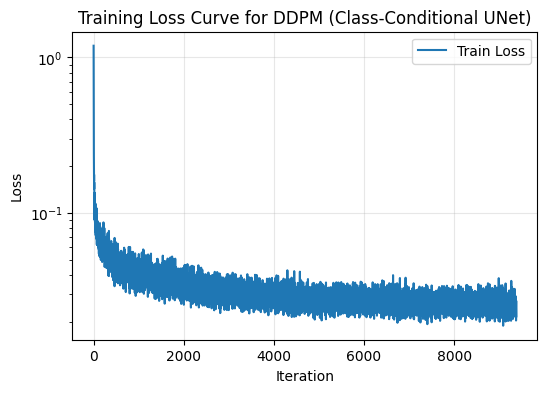

In [25]:
plt.figure(figsize=(6,4))
plt.plot(train_losses, label="Train Loss")
plt.yscale('log')
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training Loss Curve for DDPM (Class-Conditional UNet)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()